# Anharmonic phonon renormalisation with dynaphopy — EMT-Cu quick demo

A minimal end-to-end run of `calculate_phonon_md_renormalisation` (v0.0.8)
on FCC Cu with the EMT calculator, gated only on the `[phonons-md]` install
extra and runnable in CI's standard notebook environment.

For a more interesting example using a foundation model (GRACE-1L-OAM) and
a native LAMMPS MD driver side by side, see
[`dynaphopy_grace_example.ipynb`](dynaphopy_grace_example.ipynb).
That one is excluded from CI's `build-notebooks` job because it requires a
custom env with `tensorpotential` + a `pair_style grace`-capable LAMMPS
build.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import matplotlib.pyplot as plt
from ase.build import bulk
from ase.calculators.emt import EMT

## Structure + engines

FCC Cu seed structure (conventional 4-atom cubic — required because
`optimise_cubic_lattice_parameter` interprets `v0` as the volume of a
conventional cubic cell when computing `a0 = v0**(1/3)`). We use two
engines sharing the same EMT calculator: `engine_min` for the lat-opt
EOS scan (relaxation), and `engine_static` for the phonon-MD macro
(statics).

In [2]:
from pyiron_workflow_atomistics.engine import (
    ASEEngine,
    CalcInputMinimize,
    CalcInputStatic,
)

calculator = EMT()
cu = bulk("Cu", "fcc", a=3.6, cubic=True)  # 4-atom conventional, seed for EOS

engine_min = ASEEngine(
    EngineInput=CalcInputMinimize(
        force_convergence_tolerance=0.05, max_iterations=100
    ),
    calculator=calculator,
    working_directory="./_dynaphopy_emt_runs",
)
engine_static = ASEEngine(
    EngineInput=CalcInputStatic(),
    calculator=calculator,
    working_directory="./_dynaphopy_emt_runs",
)
print(f"Structure: {cu.get_chemical_formula()}  ({len(cu)} atoms)")

Structure: Cu4  (4 atoms)


## Wire lat-opt + phonon-MD into one Workflow

Parent `Workflow` does two things in order:

1. `optimise_cubic_lattice_parameter` runs a cheap 5-point EOS scan
   (strain range ±2 %) to remove any residual stress on the primitive
   cell before MD starts. Returns the equilibrium structure at the
   fitted `a0`.
2. `calculate_phonon_md_renormalisation` consumes that equilibrium
   structure with the static engine. `q_points=None` auto-derives a
   high-symmetry band path via `ase.dft.kpoints.bandpath`, returning a
   discretised dispersion of harmonic and renormalised frequencies.
   EMT-Cu is essentially harmonic so this primarily serves as an
   end-to-end workflow smoke test the CI can run cheaply.

In [3]:
from pyiron_workflow import Workflow
from pyiron_workflow_atomistics.physics.bulk import (
    optimise_cubic_lattice_parameter,
)
from pyiron_workflow_atomistics.physics.phonons import (
    calculate_phonon_md_renormalisation,
)

wf = Workflow("dynaphopy_emt")
wf.lat_opt = optimise_cubic_lattice_parameter(
    structure=cu,
    name="Cu",
    crystalstructure="fcc",
    engine=engine_min.with_working_directory("lat_opt"),
    strain_range=(-0.02, 0.02),
    num_points=5,
)
wf.phonon = calculate_phonon_md_renormalisation(
    structure=wf.lat_opt.outputs.equil_struct,
    engine=engine_static.with_working_directory("phonon"),
    fc2_supercell_matrix=2 * np.eye(3, dtype=int),
    temperature=300.0,
    equilibration_steps=200,
    production_steps=2000,
    time_step=1.0,
    thermostat_time_constant=100.0,
    q_points=None,                          # ASE-auto high-symmetry band path
    band_npoints=15,                        # coarse path for speed
    seed=42,
    power_spectra=False,
    keep_handles=False,
)
wf.run()

a0 = wf.lat_opt.outputs.a0.value
out = wf.phonon.outputs.md_phonon_output.value
print(f"optimised a0:     {a0:.4f} A  (vs. hardcoded seed 3.6000 A)")
print(f"converged:        {out.converged}")
print(f"⟨T⟩ measured:     {out.md_temperature_mean:.1f} K  (target {out.temperature:.0f} K)")
print(f"σ_T:              {out.md_temperature_std:.1f} K")
print(f"q_points shape:   {out.q_points.shape}")
print(f"harmonic shape:   {out.harmonic_frequencies.shape}")
print(f"renormalised dispersion (mean over q, per band, THz):")
print(np.nanmean(out.renormalised_frequencies, axis=0))

      Step     Time          Energy          fmax
BFGS:    0 18:02:53        0.026625        0.000000
      Step     Time          Energy          fmax
BFGS:    0 18:02:53       -0.018891        0.000000
      Step     Time          Energy          fmax
BFGS:    0 18:02:53       -0.026755        0.000000
      Step     Time          Energy          fmax
BFGS:    0 18:02:53       -0.000405        0.000000
      Step     Time          Energy          fmax
BFGS:    0 18:02:53        0.056968        0.000000


/home/liger/miniforge3/envs/test_pyiron_workflow_atomistics/lib/python3.11/site-packages/ase/md/langevin.py:110: FutureWarning: The implementation of `fixcm=True` in `Langevin` does not strictly sample the correct NVT distributions. The deviations are typically small for large systems but can be more pronounced for small systems. Use `fixcm=False` together with `ase.constraints.FixCom`. `fixcm` is deprecated since ASE 3.28.0 and will be removed in a future release.
  warnings.warn(msg, FutureWarning)


No velocity provided! calculating it from coordinates...
MD cell size relation: [2 2 2]
Using 2000 steps
Calculating phonon projection power spectra
Projecting into phonon mode
Projecting into wave vector


Harmonic frequencies (THz):
[-3.82488948e-06 -3.82339777e-06 -3.81835404e-06  9.58234982e+00
  9.58234982e+00  9.58234982e+00  9.58234982e+00  9.58234982e+00
  9.58234982e+00  1.41054691e+01  1.41054691e+01  1.41054691e+01]



Peak # 1
----------------------------------------------
Width                             0.044451 THz
Position                          6.599847 THz
Area (<K>)    (Lorentzian)        0.703282 eV
Area (<K>)    (Total)            18.970031 eV
<|dQ/dt|^2>                       1.406564 eV
Base line                         0.455168 eV * ps
Maximum height                   10.072301 eV * ps
Fitting global error              0.007532
Frequency shift                   6.599851 THz

Peak # 2
----------------------------------------------
Width                             0.044451 THz
Position                          6.599847 THz
Area (<K>)    (Lorentzian)        0.703282 eV
Area (<K>)    (Total)            18.970031 eV
<|dQ/dt|^2>                       1.406564 eV
Base line                         0.455168 eV * ps
Maximum height                   10.072301 eV * ps
Fitting global error              0.007532
Frequency shift                   6.599851 THz

Peak # 3
----------------------------

...

Projecting into phonon mode
Projecting into wave vector
warning! This wave vector is not a commensurate q-point in MD supercell


Harmonic frequencies (THz):
[ 6.13930728  6.13930728  6.13930728  6.13930728  7.77371719  7.77371719
  7.77371719  7.77371719 13.2897626  13.2897626  13.2897626  13.2897626 ]


Harmonic frequencies (THz):
[ 6.13930728  6.13930728  6.13930728  6.13930728  7.77371719  7.77371719
  7.77371719  7.77371719 13.2897626  13.2897626  13.2897626  13.2897626 ]

Peak # 1
----------------------------------------------
Width                             0.200483 THz
Position                          4.785686 THz
Area (<K>)    (Lorentzian)        0.523956 eV
Area (<K>)    (Total)            21.640278 eV
<|dQ/dt|^2>                       1.047912 eV
Base line                         0.525779 eV * ps
Maximum height                    1.663788 eV * ps
Fitting global error              0.024115
Frequency shift                  -1.353621 THz

Peak # 2
----------------------------------------------
Width                             0.200483 THz
Position                          4.785686 THz
Area (<K>)    (Lorentzian)        0.523956 eV
Area (<K>)    (Total)            21.640278 eV
<|dQ/dt|^2>                       1.047912 eV
Base line                         0.525779 eV * ps
Maxi

Harmonic frequencies (THz):
[ 6.14606681  6.14606681  6.14606681  6.14606681  6.14606681  6.14606681
  6.14606681  6.14606681 13.98086649 13.98086649 13.98086649 13.98086649]



Peak # 1
----------------------------------------------
Width                             0.044357 THz
Position                         21.496679 THz
Area (<K>)    (Lorentzian)        0.209206 eV
Area (<K>)    (Total)            22.215977 eV
<|dQ/dt|^2>                       0.418412 eV
Base line                         0.549831 eV * ps
Maximum height                    3.002537 eV * ps
Fitting global error              0.027505
Frequency shift                  15.350612 THz

Peak # 2
----------------------------------------------
Width                             0.044357 THz
Position                         21.496679 THz
Area (<K>)    (Lorentzian)        0.209206 eV
Area (<K>)    (Total)            22.215977 eV
<|dQ/dt|^2>                       0.418412 eV
Base line                         0.549831 eV * ps
Maximum height                    3.002537 eV * ps
Fitting global error              0.027505
Frequency shift                  15.350612 THz

Peak # 3
----------------------------

## Plot — phonon dispersion along the ASE-auto band path

Lines = harmonic dispersion (phonopy at each q-point on the band path).
Markers = MD-projected renormalised frequencies (dynaphopy fit per band).
EMT-Cu is essentially harmonic, so the two should track each other up
to short-MD fit noise.

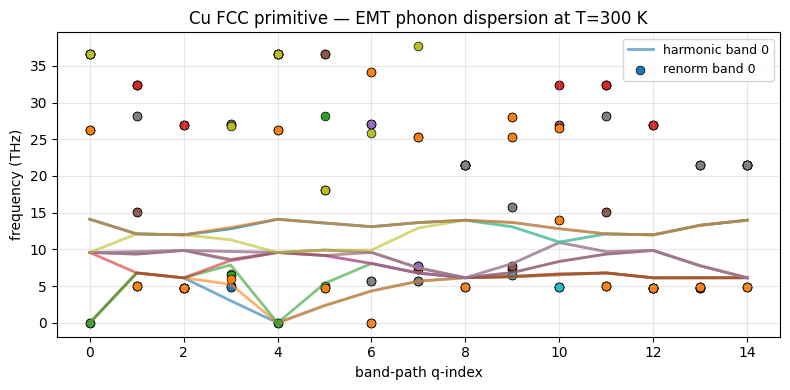

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
q_index = np.arange(out.q_points.shape[0])
for b in range(out.harmonic_frequencies.shape[1]):
    ax.plot(q_index, out.harmonic_frequencies[:, b], color=f"C{b}", lw=2, alpha=0.6,
            label=f"harmonic band {b}" if b == 0 else None)
    ax.scatter(q_index, out.renormalised_frequencies[:, b], color=f"C{b}", marker="o",
               s=40, edgecolor="black", linewidth=0.5,
               label=f"renorm band {b}" if b == 0 else None)
ax.set_xlabel("band-path q-index")
ax.set_ylabel("frequency (THz)")
ax.set_title("Cu FCC primitive — EMT phonon dispersion at T=300 K")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## What else the macro offers

- `q_points=None` (default) → auto-derived high-symmetry band path
  from `ase.dft.kpoints.bandpath`, useful for plotting dispersion.
- `phono3py_output=...` → reuse FC2 from a prior
  `calculate_phonon_thermal_conductivity` run, skipping the
  displacement-force fit entirely.
- `keep_handles=True` → keep the `dynaphopy.Quasiparticle`,
  `Dynamics`, and `phonopy.Phonopy` objects on `MdPhononOutput` for
  deeper inspection.
- `MdPhononOutput.check_md_health()` → flags ⟨T⟩ drift or σ_T anomalies;
  the macro auto-warns at completion if either heuristic trips.